# IMDb Sentiment Analysis

# 03 - Huấn luyện ba mô hình Transformer

Notebook này fine-tune ba kiến trúc Transformer khác nhau gồm DistilBERT, BERT-base và RoBERTa cho bài toán phân tích cảm xúc trên bộ dữ liệu IMDb. Mục tiêu là đánh giá liệu các mô hình ngữ cảnh hóa có cải thiện so với baseline TF-IDF + Logistic Regression hay không, đồng thời so sánh hiệu năng, thời gian huấn luyện và chi phí lưu trữ giữa các kiến trúc.

Thí nghiệm được thiết kế theo hướng có kiểm soát: toàn bộ siêu tham số chính như độ dài chuỗi, batch size, số epoch, learning rate, weight decay, warmup ratio và gradient clipping được giữ cố định. Vì vậy, biến độc lập chính trong thí nghiệm là kiến trúc mô hình, tokenizer và chiến lược pretraining của từng backbone.

Notebook sẽ phân tích quá trình huấn luyện, đường cong train/validation, tốc độ hội tụ và dấu hiệu overfitting của từng mô hình.

## 1. Tổng quan và thiết kế thí nghiệm

Ba mô hình Transformer được chọn nhằm kiểm tra các mức đánh đổi khác nhau giữa hiệu năng và chi phí tính toán.

DistilBERT đại diện cho hướng mô hình nhỏ gọn. Mô hình này được tạo ra bằng knowledge distillation, nên giả thuyết đặt ra là DistilBERT có thể giữ được phần lớn năng lực biểu diễn của BERT trong khi giảm đáng kể thời gian huấn luyện và kích thước checkpoint.

BERT-base đóng vai trò là mốc Transformer chuẩn. Đây là kiến trúc 12-layer phổ biến, dùng WordPiece tokenizer và được pretrain bằng Masked Language Modeling kết hợp Next Sentence Prediction. Trong thí nghiệm này, BERT-base được dùng để đánh giá mức cải thiện của Transformer đầy đủ so với DistilBERT.

RoBERTa được đưa vào để kiểm tra tác động của pretraining cải tiến. So với BERT, RoBERTa loại bỏ nhiệm vụ Next Sentence Prediction, sử dụng dynamic masking và được huấn luyện với chiến lược pretraining mạnh hơn. Vì vậy, giả thuyết là RoBERTa sẽ đạt validation F1 cao nhất, nhưng có chi phí huấn luyện và lưu trữ lớn hơn.

Để bảo đảm so sánh công bằng, toàn bộ siêu tham số chính được giữ cố định giữa ba mô hình: `MAX_LENGTH=256`, `BATCH_SIZE=16`, `EPOCHS=3`, `LEARNING_RATE=2e-5`, `WEIGHT_DECAY=0.01`, `WARMUP_RATIO=0.1` và `MAX_GRAD_NORM=1.0`. Cả ba mô hình đều được full fine-tuning, nghĩa là toàn bộ pretrained backbone và classification head đều được cập nhật.

Với thiết kế này, khác biệt chính giữa các thí nghiệm đến từ kiến trúc mô hình, tokenizer và phương pháp pretraining. Cách tổ chức này giúp việc so sánh giữa các mô hình tập trung vào năng lực biểu diễn của từng backbone, thay vì bị nhiễu bởi khác biệt về cấu hình huấn luyện.

## 2. Thiết lập môi trường

Trước khi huấn luyện, môi trường thực thi cần được chuẩn hóa để các thí nghiệm Transformer dùng cùng cấu hình với toàn bộ dự án. Ô bên dưới nạp thư viện, thêm project root vào `sys.path`, import các module dùng chung, cố định seed, tạo thư mục đầu ra và xác định thiết bị tính toán.

Bảng cấu hình được hiển thị nhằm kiểm tra các siêu tham số chính trước khi chạy các mô hình nặng. Nếu chạy trên Colab hoặc Kaggle, cần bảo đảm GPU đã được bật trước khi bắt đầu các cell huấn luyện.

In [1]:
from pathlib import Path
import gc
import json
import os
import sys

import pandas as pd
import torch
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src import config, dataset as dataset_utils, model as model_utils, train as train_utils, visualize
from src.utils import Timer, count_parameters, ensure_dirs, get_device, set_seed

set_seed(config.SEED)
ensure_dirs()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config_table = pd.DataFrame(
    [
        {"setting": "MAX_LENGTH", "value": config.MAX_LENGTH},
        {"setting": "BATCH_SIZE", "value": config.BATCH_SIZE},
        {"setting": "EPOCHS", "value": config.EPOCHS},
        {"setting": "LEARNING_RATE", "value": config.LEARNING_RATE},
        {"setting": "WEIGHT_DECAY", "value": config.WEIGHT_DECAY},
        {"setting": "WARMUP_RATIO", "value": config.WARMUP_RATIO},
        {"setting": "MAX_GRAD_NORM", "value": config.MAX_GRAD_NORM},
    ]
)
display(config_table)


,setting,value
0,MAX_LENGTH,256.00000
1,BATCH_SIZE,16.00000
2,EPOCHS,3.00000
3,LEARNING_RATE,0.00002
4,WEIGHT_DECAY,0.01000
5,WARMUP_RATIO,0.10000
6,MAX_GRAD_NORM,1.00000


**Nhận xét:**

Bảng cấu hình xác nhận cả ba mô hình sẽ được huấn luyện trong cùng điều kiện: `MAX_LENGTH=256`, `BATCH_SIZE=16`, `EPOCHS=3`, `LEARNING_RATE=2e-5`, `WEIGHT_DECAY=0.01`, `WARMUP_RATIO=0.1` và `MAX_GRAD_NORM=1.0`.

Việc cố định các thiết lập này giúp thí nghiệm có tính kiểm soát hơn. Khi dữ liệu, độ dài chuỗi, batch size, learning rate và số epoch đều được giữ nguyên, khác biệt về validation performance có thể được quy chủ yếu cho kiến trúc mô hình, tokenizer và quá trình pretraining của từng Transformer.

## 3. So sánh kiến trúc trước khi huấn luyện

Trước khi fine-tuning, cần so sánh đặc điểm kiến trúc của DistilBERT, BERT-base và RoBERTa để hiểu trước các đánh đổi về chi phí và năng lực biểu diễn. Bảng tham chiếu dưới đây tóm tắt số layer, hidden size, số attention head, kích thước vocabulary, tokenizer và phương pháp pretraining của từng mô hình.

Các thông tin trong bảng đầu tiên mang tính định hướng. Sau đó, notebook sẽ tải mô hình thật và tính số tham số bằng cùng một hàm tiện ích để có số liệu chính xác cho thí nghiệm.


In [2]:
architecture_reference = pd.DataFrame(
    [
        {
            "model": "DistilBERT",
            "encoder_layers": 6,
            "hidden_size": 768,
            "attention_heads": 12,
            "parameters": "~67M",
            "vocab_size": 30522,
            "tokenizer": "WordPiece",
            "pretraining": "Distillation",
        },
        {
            "model": "BERT-base",
            "encoder_layers": 12,
            "hidden_size": 768,
            "attention_heads": 12,
            "parameters": "~110M",
            "vocab_size": 30522,
            "tokenizer": "WordPiece",
            "pretraining": "MLM + NSP",
        },
        {
            "model": "RoBERTa",
            "encoder_layers": 12,
            "hidden_size": 768,
            "attention_heads": 12,
            "parameters": "~125M",
            "vocab_size": 50265,
            "tokenizer": "BPE",
            "pretraining": "MLM only",
        },
    ]
)
display(architecture_reference)


,model,encoder_layers,hidden_size,attention_heads,parameters,vocab_size,tokenizer,pretraining
0,DistilBERT,6,768,12,~67M,30522,WordPiece,Distillation
1,BERT-base,12,768,12,~110M,30522,WordPiece,MLM + NSP
2,RoBERTa,12,768,12,~125M,50265,BPE,MLM only


**Nhận xét:**

Bảng tham chiếu cho thấy DistilBERT là mô hình nhẹ nhất với 6 encoder layer, trong khi BERT-base và RoBERTa đều có 12 encoder layer. DistilBERT và BERT-base dùng WordPiece tokenizer với vocabulary 30,522 token, còn RoBERTa dùng BPE tokenizer với vocabulary lớn hơn.

Về pretraining, BERT-base dùng Masked Language Modeling kết hợp Next Sentence Prediction; RoBERTa giữ MLM nhưng loại bỏ NSP và thay đổi chiến lược pretraining; DistilBERT được tạo bằng knowledge distillation để giảm kích thước mô hình. Những khác biệt này là cơ sở để kỳ vọng RoBERTa có hiệu năng cao hơn, còn DistilBERT có thời gian huấn luyện thấp hơn.

### 3.1. Kiểm tra số tham số thực tế

Ở bước này, từng mô hình pretrained được tải và đo số tham số bằng cùng một hàm tiện ích. Việc đo trực tiếp giúp tránh phụ thuộc vào các số liệu làm tròn trong tài liệu, đồng thời xác nhận liệu toàn bộ backbone có đang được đặt ở trạng thái trainable hay không.

Trong trường hợp môi trường thực thi không có quyền tải mô hình từ Hugging Face Hub, cần chạy notebook trên Colab, Kaggle hoặc một môi trường có kết nối mạng và quyền truy cập phù hợp.

In [3]:
model_summaries = []
for model_key, hf_name in config.TRANSFORMER_MODELS.items():
    loaded_model = model_utils.load_model_for_training(hf_name)
    summary = model_utils.get_model_summary(loaded_model, model_key)
    model_summaries.append(summary)
    del loaded_model
    torch.cuda.empty_cache()
    gc.collect()

display(pd.DataFrame(model_summaries))


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,name,hf_identifier,architecture_type,num_layers,hidden_size,num_attention_heads,vocab_size,total_params,trainable_params,non_trainable_params,model_size_mb,tokenizer_type
0,distilbert,distilbert-base-uncased,distilbert,6,768,12,30522,66955010,66955010,0,255.417000,WordPiece
1,bert,bert-base-uncased,bert,12,768,12,30522,109483778,109483778,0,417.655281,WordPiece
2,roberta,roberta-base,roberta,12,768,12,50265,124647170,124647170,0,475.499062,BPE


**Nhận xét:**

Số tham số thực tế xác nhận thứ tự chi phí tăng dần: DistilBERT có 66,955,010 tham số và chiếm khoảng 255.42 MB trong bộ nhớ; BERT-base có 109,483,778 tham số và khoảng 417.66 MB; RoBERTa có 124,647,170 tham số và khoảng 475.50 MB.

Vì `non_trainable_params=0` cho cả ba mô hình, toàn bộ pretrained backbone sẽ được cập nhật trong quá trình fine-tuning. Điều này làm thí nghiệm phản ánh đầy đủ năng lực thích nghi của từng mô hình, nhưng cũng khiến chi phí huấn luyện cao hơn so với phương án freeze backbone.

## 4. Huấn luyện DistilBERT

DistilBERT là mô hình đầu tiên được huấn luyện vì đây là kiến trúc nhẹ nhất trong ba Transformer. Giả thuyết ban đầu là DistilBERT sẽ có thời gian huấn luyện thấp nhất, đồng thời vẫn đạt mức validation đủ cạnh tranh nhờ kế thừa tri thức từ BERT thông qua knowledge distillation.

Phần này gồm bốn bước: nạp tokenizer và mô hình, tạo DataLoader, kiểm tra tokenization, huấn luyện và trực quan hóa đường cong train/validation. Kết quả sau huấn luyện sẽ cho biết DistilBERT có phải lựa chọn tốt khi ưu tiên tốc độ hay không.

### 4.1. Nạp mô hình và tokenizer

Phần này nạp `distilbert-base-uncased`, thêm classification head hai lớp và hiển thị tóm tắt kiến trúc. Việc kiểm tra số layer, tokenizer, số tham số và kích thước mô hình giúp bảo đảm checkpoint được tải đúng trước khi tạo DataLoader và huấn luyện.

In [4]:
distilbert_name = config.TRANSFORMER_MODELS["distilbert"]
distilbert_tokenizer = model_utils.load_tokenizer(distilbert_name)
distilbert_model = model_utils.load_model_for_training(distilbert_name)
distilbert_summary = model_utils.get_model_summary(distilbert_model, "distilbert")
display(pd.DataFrame([distilbert_summary]))


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,name,hf_identifier,architecture_type,num_layers,hidden_size,num_attention_heads,vocab_size,total_params,trainable_params,non_trainable_params,model_size_mb,tokenizer_type
0,distilbert,distilbert-base-uncased,distilbert,6,768,12,30522,66955010,66955010,0,255.417,WordPiece


**Nhận xét:**

Tóm tắt mô hình xác nhận DistilBERT dùng WordPiece tokenizer, có 6 encoder layer, hidden size 768, 12 attention head và 66,955,010 tham số trainable. Kích thước checkpoint sau khi lưu là khoảng 256.10 MB.

Đây là mô hình nhỏ nhất trong ba Transformer của notebook, nên nó được kỳ vọng có tốc độ huấn luyện nhanh nhất. Tuy nhiên, việc có ít layer hơn cũng có thể làm giảm khả năng biểu diễn các quan hệ ngữ cảnh phức tạp trong review dài. Vì vậy, DistilBERT là lựa chọn phù hợp để kiểm tra đánh đổi giữa tốc độ và hiệu năng.


### 4.2. Tạo DataLoader và kiểm tra tokenization

DataLoader chuyển từng review thành các tensor `input_ids`, `attention_mask` và `label`. Với `BATCH_SIZE=16` và `MAX_LENGTH=256`, mỗi batch đầu vào có dạng phù hợp để đưa trực tiếp vào mô hình Transformer.

Bên cạnh shape của batch, notebook cũng hiển thị một ví dụ tokenization để kiểm tra cách tokenizer xử lý từ hiếm và subword. Đây là bước hữu ích trước khi huấn luyện vì lỗi tokenization hoặc shape sai sẽ ảnh hưởng trực tiếp đến toàn bộ pipeline.

In [5]:
distilbert_train_loader, distilbert_val_loader, distilbert_test_loader = dataset_utils.create_dataloaders(
    distilbert_tokenizer,
    max_length=config.MAX_LENGTH,
    batch_size=config.BATCH_SIZE,
    num_workers=0,
)

batch = next(iter(distilbert_train_loader))
shape_table = pd.DataFrame(
    [
        {"tensor": key, "shape": tuple(value.shape)}
        for key, value in batch.items()
    ]
)
display(shape_table)

example_text = dataset_utils.load_data("train")[0][0]
distilbert_tokens = distilbert_tokenizer.tokenize(example_text)[:40]
distilbert_ids = distilbert_tokenizer.convert_tokens_to_ids(distilbert_tokens)
display(pd.DataFrame({"token": distilbert_tokens, "token_id": distilbert_ids}).head(40))
print(distilbert_tokenizer.decode(distilbert_ids))


,tensor,shape
0,input_ids,"(16, 256)"
1,attention_mask,"(16, 256)"
2,label,"(16,)"


,token,token_id
0,i,1045
1,am,2572
2,one,2028
3,of,1997
4,je,15333
5,##ho,6806
6,##vah,21927
7,',1005
8,s,1055
9,witnesses,9390


i am one of jehovah ' s witnesses and i also work in an acute care medical facility. over the years i have seen people die from hemolytic reactions to blood transfusions,


**Nhận xét:**

Batch kiểm tra có đúng shape: `input_ids` là `(16, 256)`, `attention_mask` là `(16, 256)` và `label` là `(16,)`. Điều này xác nhận DataLoader đang trả về đúng định dạng đầu vào cho bài toán phân loại hai lớp.

Ví dụ tokenization cho thấy WordPiece tách `Jehovah` thành các mảnh `je`, `##ho`, `##vah`. Cách tách này giúp tokenizer xử lý các từ hiếm hoặc ngoài vocabulary bằng cách biểu diễn chúng dưới dạng các subword nhỏ hơn, thay vì gán toàn bộ từ vào một token không xác định.

### 4.3. Huấn luyện và lưu checkpoint

Thí nghiệm giữ nguyên toàn bộ hyperparameter trong `src.config`, bao gồm optimizer, learning rate scheduler, warmup, gradient clipping và early stopping. Việc cố định cấu hình giúp kết quả của DistilBERT có thể so sánh trực tiếp với BERT-base và RoBERTa ở các phần sau.

Checkpoint tốt nhất được lưu khi validation loss cải thiện. Trong quá trình huấn luyện, notebook ghi lại train loss, validation loss, validation accuracy và validation F1 theo từng epoch để đánh giá tốc độ hội tụ, khả năng tổng quát hóa và dấu hiệu overfitting.

In [6]:
with Timer() as distilbert_timer:
    distilbert_result = train_utils.train_model(
        "distilbert",
        distilbert_model,
        distilbert_tokenizer,
        distilbert_train_loader,
        distilbert_val_loader,
        device,
    )

print(f"DistilBERT training time: {distilbert_timer}")
display(pd.DataFrame(distilbert_result["history"]))


Training:   0%|          | 0/2479 [00:00<?, ?it/s]

Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 1: train_loss=0.3016, val_loss=0.2624, val_f1=0.9098


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /kaggle/working/imdb_sentiment_analysis/models/distilbert-base-uncased (256.1 MB)


...

Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 3: train_loss=0.1018, val_loss=0.3268, val_f1=0.9195
Early stopping at epoch 3


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT training time: 29m 6s


,epoch,train_accuracy,train_f1,train_loss,val_accuracy,val_f1,val_loss,learning_rate,epoch_time_seconds
0,1,0.869958,0.869906,0.301551,0.909843,0.909752,0.262382,0.000015,582.604445
1,2,0.942391,0.942390,0.172154,0.921944,0.921940,0.272477,0.000007,582.639985
2,3,0.972418,0.972418,0.101836,0.919524,0.919514,0.326762,0.000000,579.616410


**Nhận xét:**

DistilBERT đạt validation F1 90.98% ở epoch 1, tăng lên 92.19% ở epoch 2 và giảm nhẹ còn 91.95% ở epoch 3. Validation accuracy cao nhất cũng đạt 92.19% tại epoch 2. Tuy nhiên, validation loss tốt nhất lại nằm ở epoch 1 với 0.2624; sau đó tăng lên 0.2725 ở epoch 2 và 0.3268 ở epoch 3.

Diễn biến này cho thấy mô hình tiếp tục học mạnh trên tập train, nhưng khả năng tổng quát hóa không cải thiện tương ứng. Train loss giảm từ 0.3016 xuống 0.1018, trong khi validation loss tăng sau epoch đầu, cho thấy dấu hiệu overfitting khá rõ. Early stopping kích hoạt tại epoch 3, và thời gian huấn luyện là 1,746.01 giây, tương đương khoảng 29 phút 6 giây.


### 4.4. Trực quan hóa quá trình huấn luyện

Đường cong train và validation giúp kiểm tra khoảng cách tổng quát hóa, tốc độ hội tụ và tác động của lịch learning rate. Phần trực quan hóa này dùng để đối chiếu với bảng log huấn luyện, từ đó nhận diện các xu hướng như cải thiện validation performance hoặc dấu hiệu overfitting.

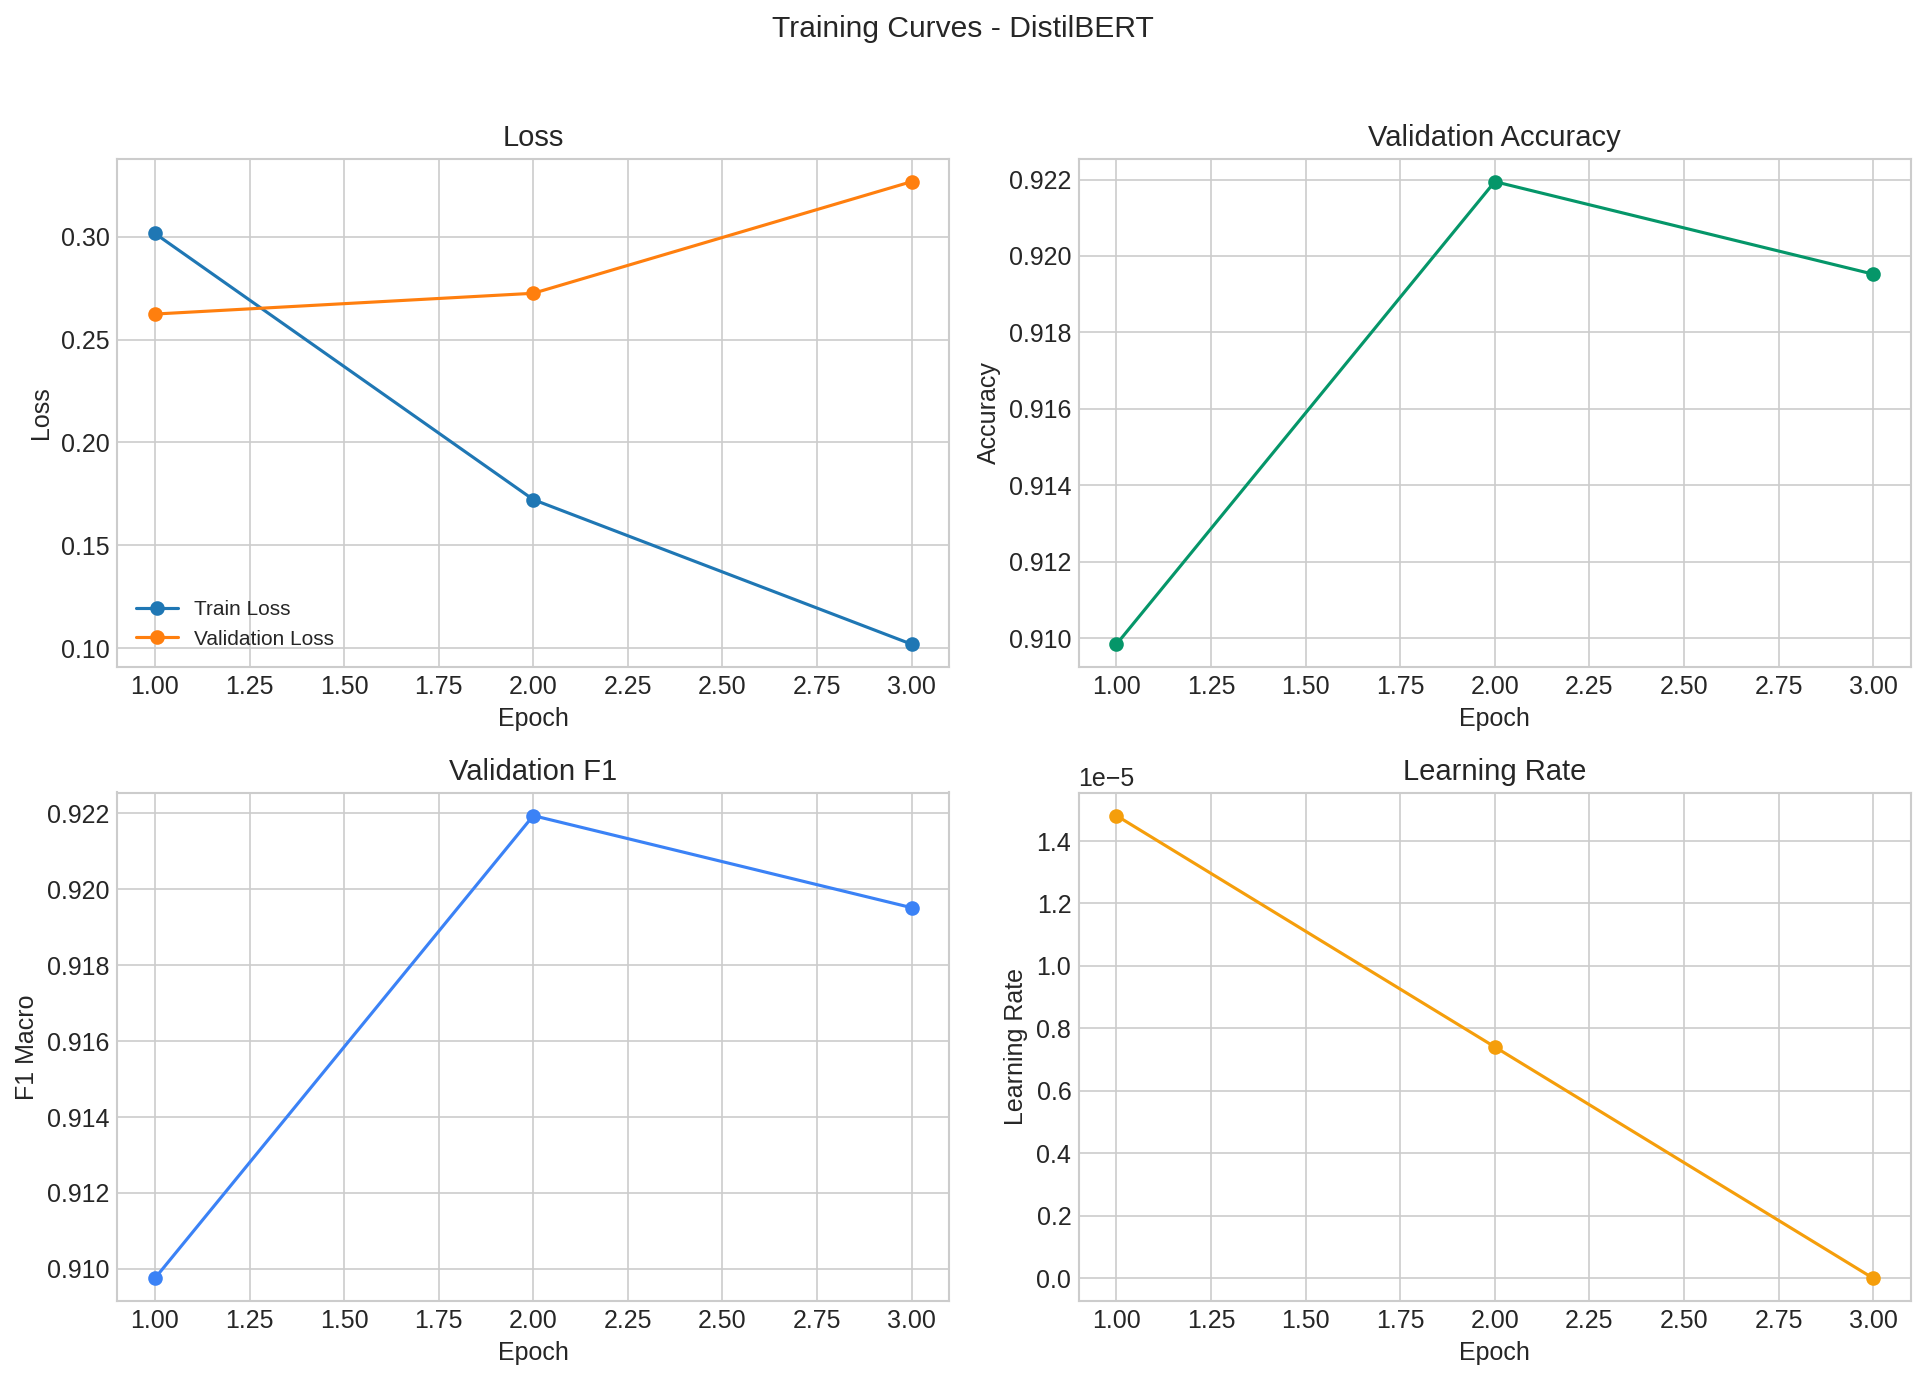

In [7]:
distilbert_curve_path = str(Path(config.FIGURES_DIR) / "training_curves_distilbert.png")
visualize.plot_training_curves(distilbert_result["history"], "DistilBERT", distilbert_curve_path)
display(Image(filename=distilbert_curve_path))


**Nhận xét:**

Biểu đồ cho thấy train loss giảm đều qua ba epoch, trong khi validation loss tăng dần sau epoch đầu. Xu hướng này nhất quán với bảng log huấn luyện và cho thấy DistilBERT bắt đầu overfit khi tiếp tục fine-tuning.

Validation accuracy và validation F1 tăng từ epoch 1 sang epoch 2, sau đó giảm nhẹ ở epoch 3. Vì vậy, epoch 2 là điểm tốt nhất nếu xét theo validation F1, còn checkpoint theo validation loss sẽ ưu tiên epoch 1. Learning rate giảm dần theo scheduler và về gần 0 ở cuối quá trình huấn luyện, cho thấy lịch học đã hoàn tất như cấu hình.

### 4.5. Giải phóng bộ nhớ

Sau khi checkpoint tốt nhất đã được lưu, biến mô hình hiện tại có thể được xóa khỏi bộ nhớ để chuẩn bị cho thí nghiệm tiếp theo. Bước này đặc biệt quan trọng khi chạy nhiều mô hình Transformer liên tiếp trong cùng một kernel.

In [8]:
del distilbert_model
torch.cuda.empty_cache()
gc.collect()


20720

**Nhận xét:**

Bộ nhớ được giải phóng sau khi checkpoint DistilBERT đã được lưu tại `models/distilbert-base-uncased/`. Điều này cần thiết vì mô hình tiếp theo, BERT-base, có số tham số lớn hơn đáng kể và yêu cầu nhiều VRAM hơn khi huấn luyện.

Việc giải phóng mô hình giữa các thí nghiệm cũng giúp giảm rủi ro lỗi hết bộ nhớ, nhất là trong môi trường Kaggle hoặc Colab có giới hạn tài nguyên GPU.

## 5. Huấn luyện BERT-base

BERT-base được dùng như mốc Transformer chuẩn để so sánh với DistilBERT và RoBERTa. So với DistilBERT, BERT-base có số encoder layer gấp đôi, do đó được kỳ vọng có khả năng biểu diễn ngữ cảnh tốt hơn nhưng cũng tốn thời gian huấn luyện và bộ nhớ hơn.

Phần này tiếp tục giữ nguyên toàn bộ hyperparameter để kết quả có thể so sánh trực tiếp với DistilBERT. Nếu BERT-base cải thiện validation F1, mức cải thiện đó cần được đặt cạnh chi phí huấn luyện tăng thêm để đánh giá tính hợp lý của mô hình.


### 5.1. Nạp mô hình, tokenizer và DataLoader mới

Dù BERT-base và DistilBERT đều dùng WordPiece tokenizer, notebook vẫn nạp tokenizer và tạo DataLoader riêng cho BERT-base. Cách làm này bảo đảm pipeline luôn khớp với checkpoint hiện tại và tránh phụ thuộc vào object còn lại từ thí nghiệm trước.

Sau khi nạp mô hình, notebook hiển thị tóm tắt kiến trúc để xác nhận số layer, số tham số và kích thước mô hình trước khi huấn luyện.


In [9]:
bert_name = config.TRANSFORMER_MODELS["bert"]
bert_tokenizer = model_utils.load_tokenizer(bert_name)
bert_model = model_utils.load_model_for_training(bert_name)
bert_summary = model_utils.get_model_summary(bert_model, "bert")
display(pd.DataFrame([bert_summary]))

bert_train_loader, bert_val_loader, bert_test_loader = dataset_utils.create_dataloaders(
    bert_tokenizer,
    max_length=config.MAX_LENGTH,
    batch_size=config.BATCH_SIZE,
    num_workers=0,
)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,name,hf_identifier,architecture_type,num_layers,hidden_size,num_attention_heads,vocab_size,total_params,trainable_params,non_trainable_params,model_size_mb,tokenizer_type
0,bert,bert-base-uncased,bert,12,768,12,30522,109483778,109483778,0,417.655281,WordPiece


**Nhận xét:**

BERT-base có 12 encoder layer, hidden size 768, 12 attention head, WordPiece tokenizer và 109,483,778 tham số trainable. So với DistilBERT, BERT-base tăng thêm khoảng 42.53 triệu tham số.

Mức tăng này giải thích vì sao BERT-base được kỳ vọng có khả năng biểu diễn tốt hơn DistilBERT, nhưng đồng thời cũng làm tăng đáng kể thời gian huấn luyện và nhu cầu bộ nhớ.

### 5.2. Huấn luyện và trực quan hóa BERT-base

Phần này dùng cùng hàm `train_model`, cùng optimizer AdamW, cùng scheduler warmup, cùng gradient clipping và cùng cơ chế early stopping như thí nghiệm DistilBERT. Việc giữ nguyên quy trình huấn luyện giúp so sánh BERT-base với DistilBERT một cách công bằng hơn.

Sau huấn luyện, notebook hiển thị lịch sử theo epoch và lưu hình đường cong huấn luyện để phân tích hội tụ, khoảng cách train-validation và dấu hiệu overfitting.


Training:   0%|          | 0/2479 [00:00<?, ?it/s]

Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 1: train_loss=0.2905, val_loss=0.2257, val_f1=0.9174


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /kaggle/working/imdb_sentiment_analysis/models/bert-base-uncased (418.3 MB)


...

Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 3: train_loss=0.0883, val_loss=0.3303, val_f1=0.9270
Early stopping at epoch 3


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT training time: 53m 17s


,epoch,train_accuracy,train_f1,train_loss,val_accuracy,val_f1,val_loss,learning_rate,epoch_time_seconds
0,1,0.879362,0.879353,0.290459,0.917507,0.917434,0.225715,0.000015,1065.634285
1,2,0.950207,0.950206,0.159416,0.927793,0.927782,0.235368,0.000007,1063.280270
2,3,0.977158,0.977158,0.088310,0.926987,0.926977,0.330340,0.000000,1066.070185


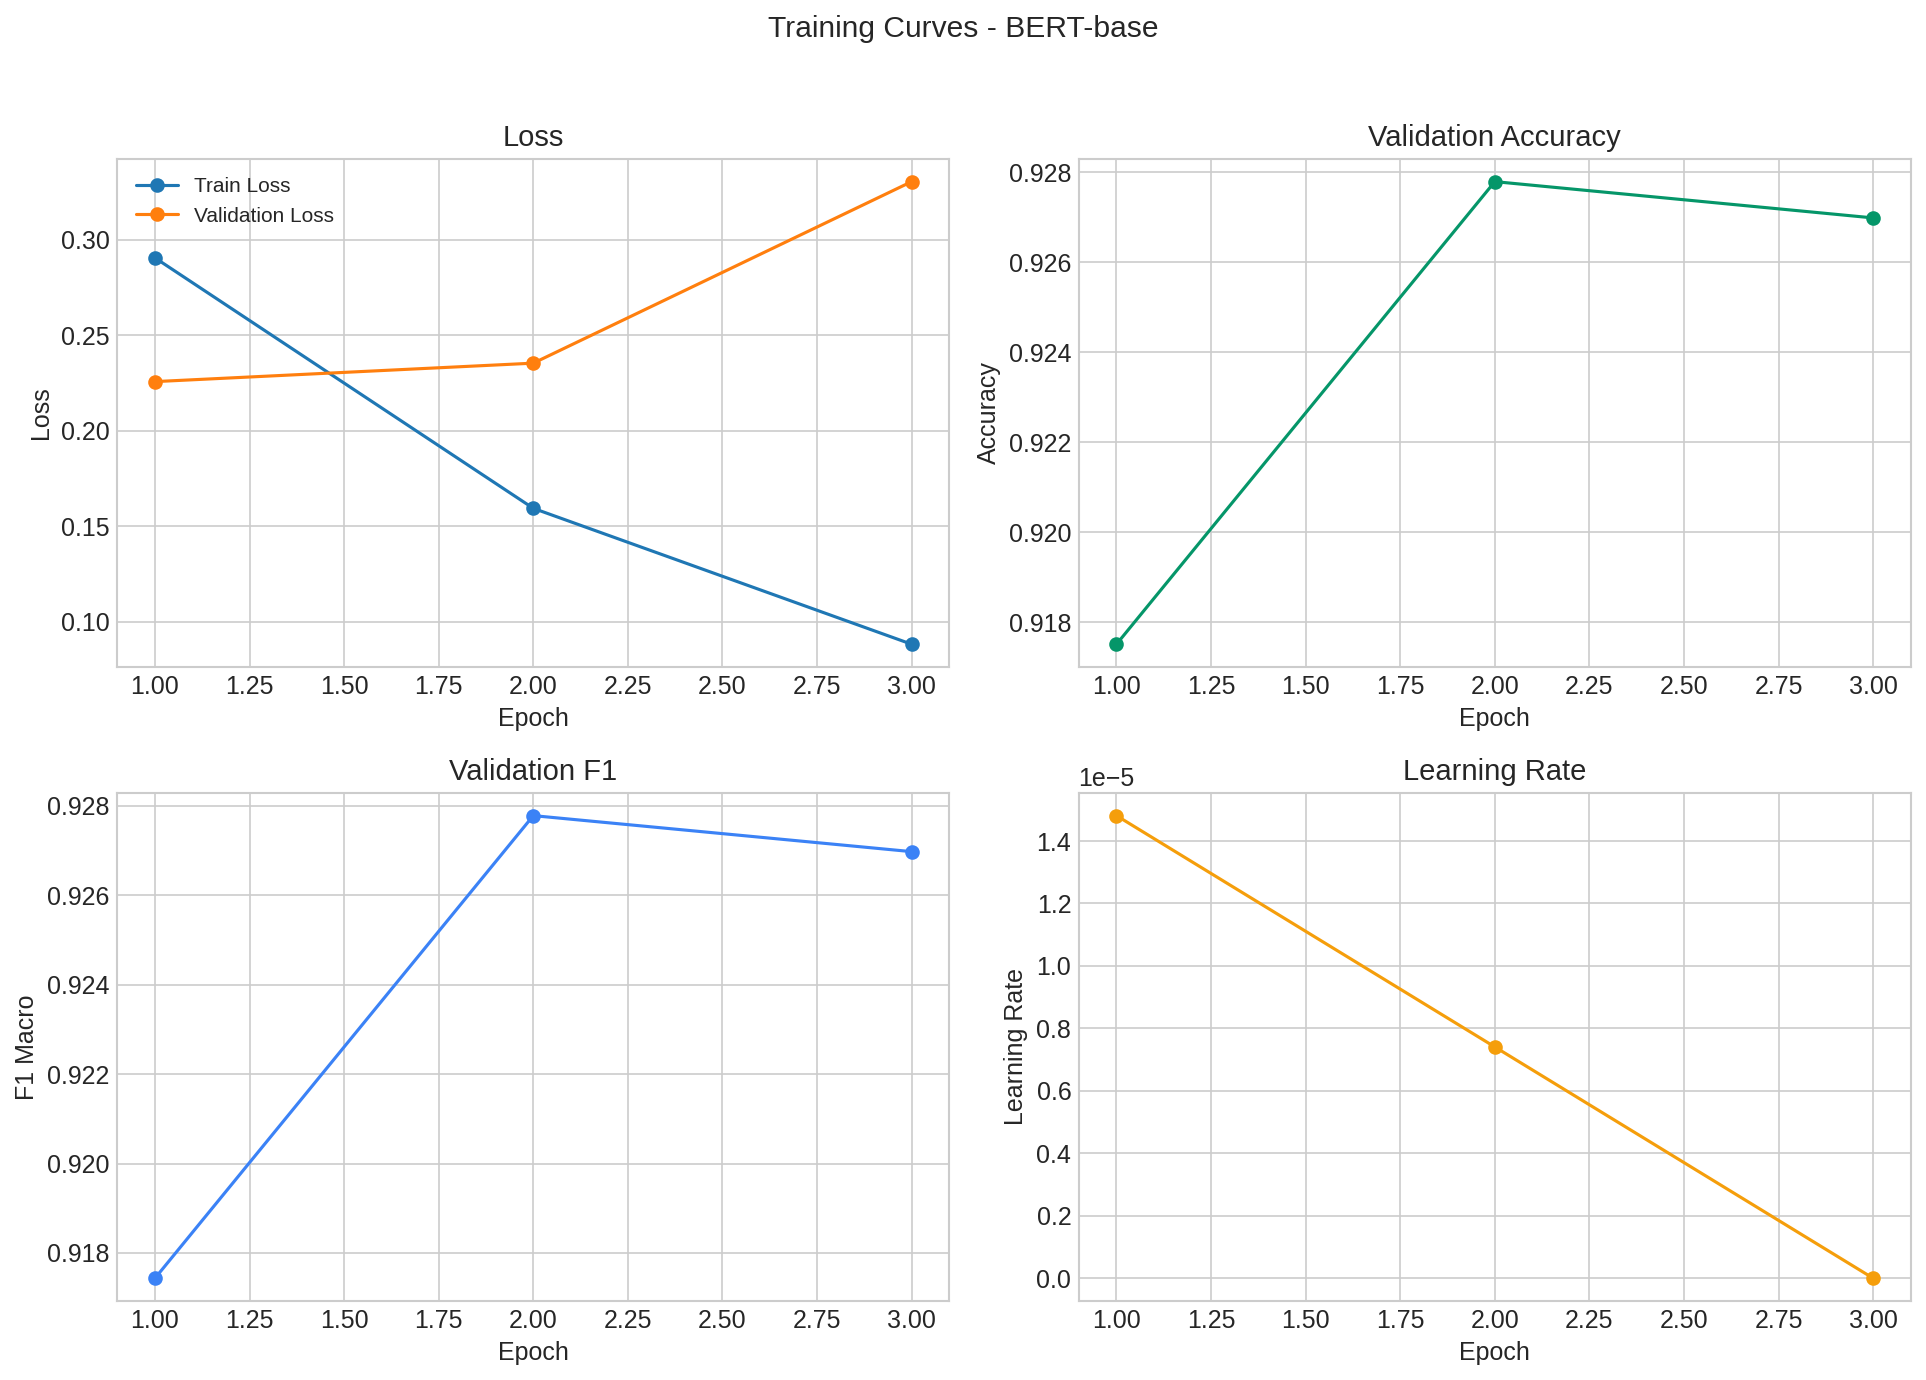

In [10]:
with Timer() as bert_timer:
    bert_result = train_utils.train_model(
        "bert",
        bert_model,
        bert_tokenizer,
        bert_train_loader,
        bert_val_loader,
        device,
    )

print(f"BERT training time: {bert_timer}")
display(pd.DataFrame(bert_result["history"]))

bert_curve_path = str(Path(config.FIGURES_DIR) / "training_curves_bert.png")
visualize.plot_training_curves(bert_result["history"], "BERT-base", bert_curve_path)
display(Image(filename=bert_curve_path))


**Nhận xét:**

BERT-base đạt validation F1 91.74% ở epoch 1, tăng lên 92.78% ở epoch 2 và giảm nhẹ còn 92.70% ở epoch 3. Validation accuracy cao nhất cũng đạt 92.78% tại epoch 2. Tuy nhiên, validation loss tốt nhất là 0.2257 ở epoch 1; sau đó tăng lên 0.2354 ở epoch 2 và 0.3303 ở epoch 3.

Kết quả này cho thấy BERT-base cải thiện validation F1 so với DistilBERT, nhưng vẫn xuất hiện dấu hiệu overfitting khi train loss giảm sâu từ 0.2905 xuống 0.0883 trong khi validation loss tăng. Thời gian huấn luyện là 3,196.38 giây, tương đương khoảng 53 phút 16 giây, dài hơn DistilBERT khoảng 1,450 giây.

Đường cong huấn luyện củng cố nhận định từ bảng log: mô hình tiếp tục tối ưu rất tốt trên tập train, nhưng validation loss không cải thiện sau epoch đầu. Nếu chọn checkpoint theo validation loss, epoch 1 là lựa chọn an toàn hơn; nếu xét theo validation F1, epoch 2 cho kết quả tốt nhất.

### 5.3. Giải phóng bộ nhớ

Checkpoint tốt nhất của BERT-base đã được lưu trong thư mục mô hình, nên có thể xóa biến mô hình hiện tại trước khi chạy RoBERTa. Đây là bước quan trọng vì RoBERTa có số tham số và kích thước vocabulary lớn hơn.


In [11]:
del bert_model
torch.cuda.empty_cache()
gc.collect()


13474

**Nhận xét:**

Bộ nhớ được giải phóng sau khi checkpoint BERT-base đã được lưu tại `models/bert-base-uncased/`. Bước này giúp chuẩn bị tài nguyên cho RoBERTa, mô hình có checkpoint lớn hơn và vocabulary khác so với WordPiece.

Việc giải phóng bộ nhớ sau từng mô hình cũng giúp notebook ổn định hơn khi chạy liên tục từ đầu đến cuối.

## 6. Huấn luyện RoBERTa

RoBERTa là mô hình Transformer cuối cùng trong notebook và được kỳ vọng đạt validation tốt nhất nhờ các thay đổi quan trọng trong pretraining: dữ liệu huấn luyện lớn hơn, dynamic masking, chiến lược huấn luyện được tối ưu hơn và loại bỏ nhiệm vụ Next Sentence Prediction.

Tuy nhiên, RoBERTa cũng có số tham số và kích thước checkpoint lớn nhất trong ba mô hình. Vì vậy, phần này không chỉ kiểm tra hiệu năng validation mà còn xem chi phí huấn luyện của RoBERTa có hợp lý so với BERT-base và DistilBERT hay không.

### 6.1. Nạp mô hình, tokenizer và DataLoader mới

RoBERTa dùng BPE tokenizer với vocabulary khác WordPiece, nên cần tạo DataLoader mới thay vì tái sử dụng DataLoader của BERT-base. Điều này bảo đảm input_ids và tokenization khớp chính xác với embedding matrix của RoBERTa.

Notebook cũng so sánh tokenization của cùng một review giữa BERT và RoBERTa để minh họa sự khác biệt giữa WordPiece và BPE.


In [12]:
roberta_name = config.TRANSFORMER_MODELS["roberta"]
roberta_tokenizer = model_utils.load_tokenizer(roberta_name)
roberta_model = model_utils.load_model_for_training(roberta_name)
roberta_summary = model_utils.get_model_summary(roberta_model, "roberta")
display(pd.DataFrame([roberta_summary]))

roberta_train_loader, roberta_val_loader, roberta_test_loader = dataset_utils.create_dataloaders(
    roberta_tokenizer,
    max_length=config.MAX_LENGTH,
    batch_size=config.BATCH_SIZE,
    num_workers=0,
)

comparison_tokens = pd.DataFrame(
    {
        "bert_wordpiece": bert_tokenizer.tokenize(example_text)[:40],
        "roberta_bpe": roberta_tokenizer.tokenize(example_text)[:40],
    }
)
display(comparison_tokens)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,name,hf_identifier,architecture_type,num_layers,hidden_size,num_attention_heads,vocab_size,total_params,trainable_params,non_trainable_params,model_size_mb,tokenizer_type
0,roberta,roberta-base,roberta,12,768,12,50265,124647170,124647170,0,475.499062,BPE


,bert_wordpiece,roberta_bpe
0,i,I
1,am,Ġam
2,one,Ġone
3,of,Ġof
4,je,ĠJehovah
5,##ho,'s
6,##vah,ĠWitnesses
7,',Ġand
8,s,ĠI
9,witnesses,Ġalso


**Nhận xét:**

RoBERTa dùng BPE tokenizer với vocabulary 50,265 token và có 124,647,170 tham số trainable. Bảng tokenization cho thấy cùng một review được tách khác rõ rệt so với BERT: RoBERTa dùng ký hiệu khoảng trắng `Ġ` và các mảnh BPE, trong khi BERT dùng WordPiece với tiền tố `##`.

Sự khác biệt tokenizer này có thể ảnh hưởng đến cách mô hình biểu diễn từ hiếm, dấu câu và ranh giới từ. Vì vậy, việc tạo DataLoader riêng cho RoBERTa là bắt buộc để tránh mismatch giữa tokenizer và mô hình.

### 6.2. Huấn luyện và trực quan hóa RoBERTa

Phần này lặp lại quy trình huấn luyện với cùng hyperparameter như DistilBERT và BERT-base. Nhờ đó, kết quả validation của RoBERTa có thể được so sánh trực tiếp với hai mô hình trước.

Sau khi huấn luyện, notebook lưu checkpoint tốt nhất theo validation loss, hiển thị lịch sử theo epoch và tạo hình training curve để phân tích hội tụ.


Training:   0%|          | 0/2479 [00:00<?, ?it/s]

Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 1: train_loss=0.2700, val_loss=0.2138, val_f1=0.9297


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /kaggle/working/imdb_sentiment_analysis/models/roberta-base (478.9 MB)


...

Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 3: train_loss=0.0953, val_loss=0.2639, val_f1=0.9451


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa training time: 53m 25s


,epoch,train_accuracy,train_f1,train_loss,val_accuracy,val_f1,val_loss,learning_rate,epoch_time_seconds
0,1,0.893279,0.893272,0.270027,0.929810,0.929735,0.213842,0.000015,1067.572100
1,2,0.953686,0.953685,0.158569,0.942517,0.942516,0.209570,0.000007,1066.559302
2,3,0.977108,0.977107,0.095338,0.945139,0.945135,0.263925,0.000000,1067.557497


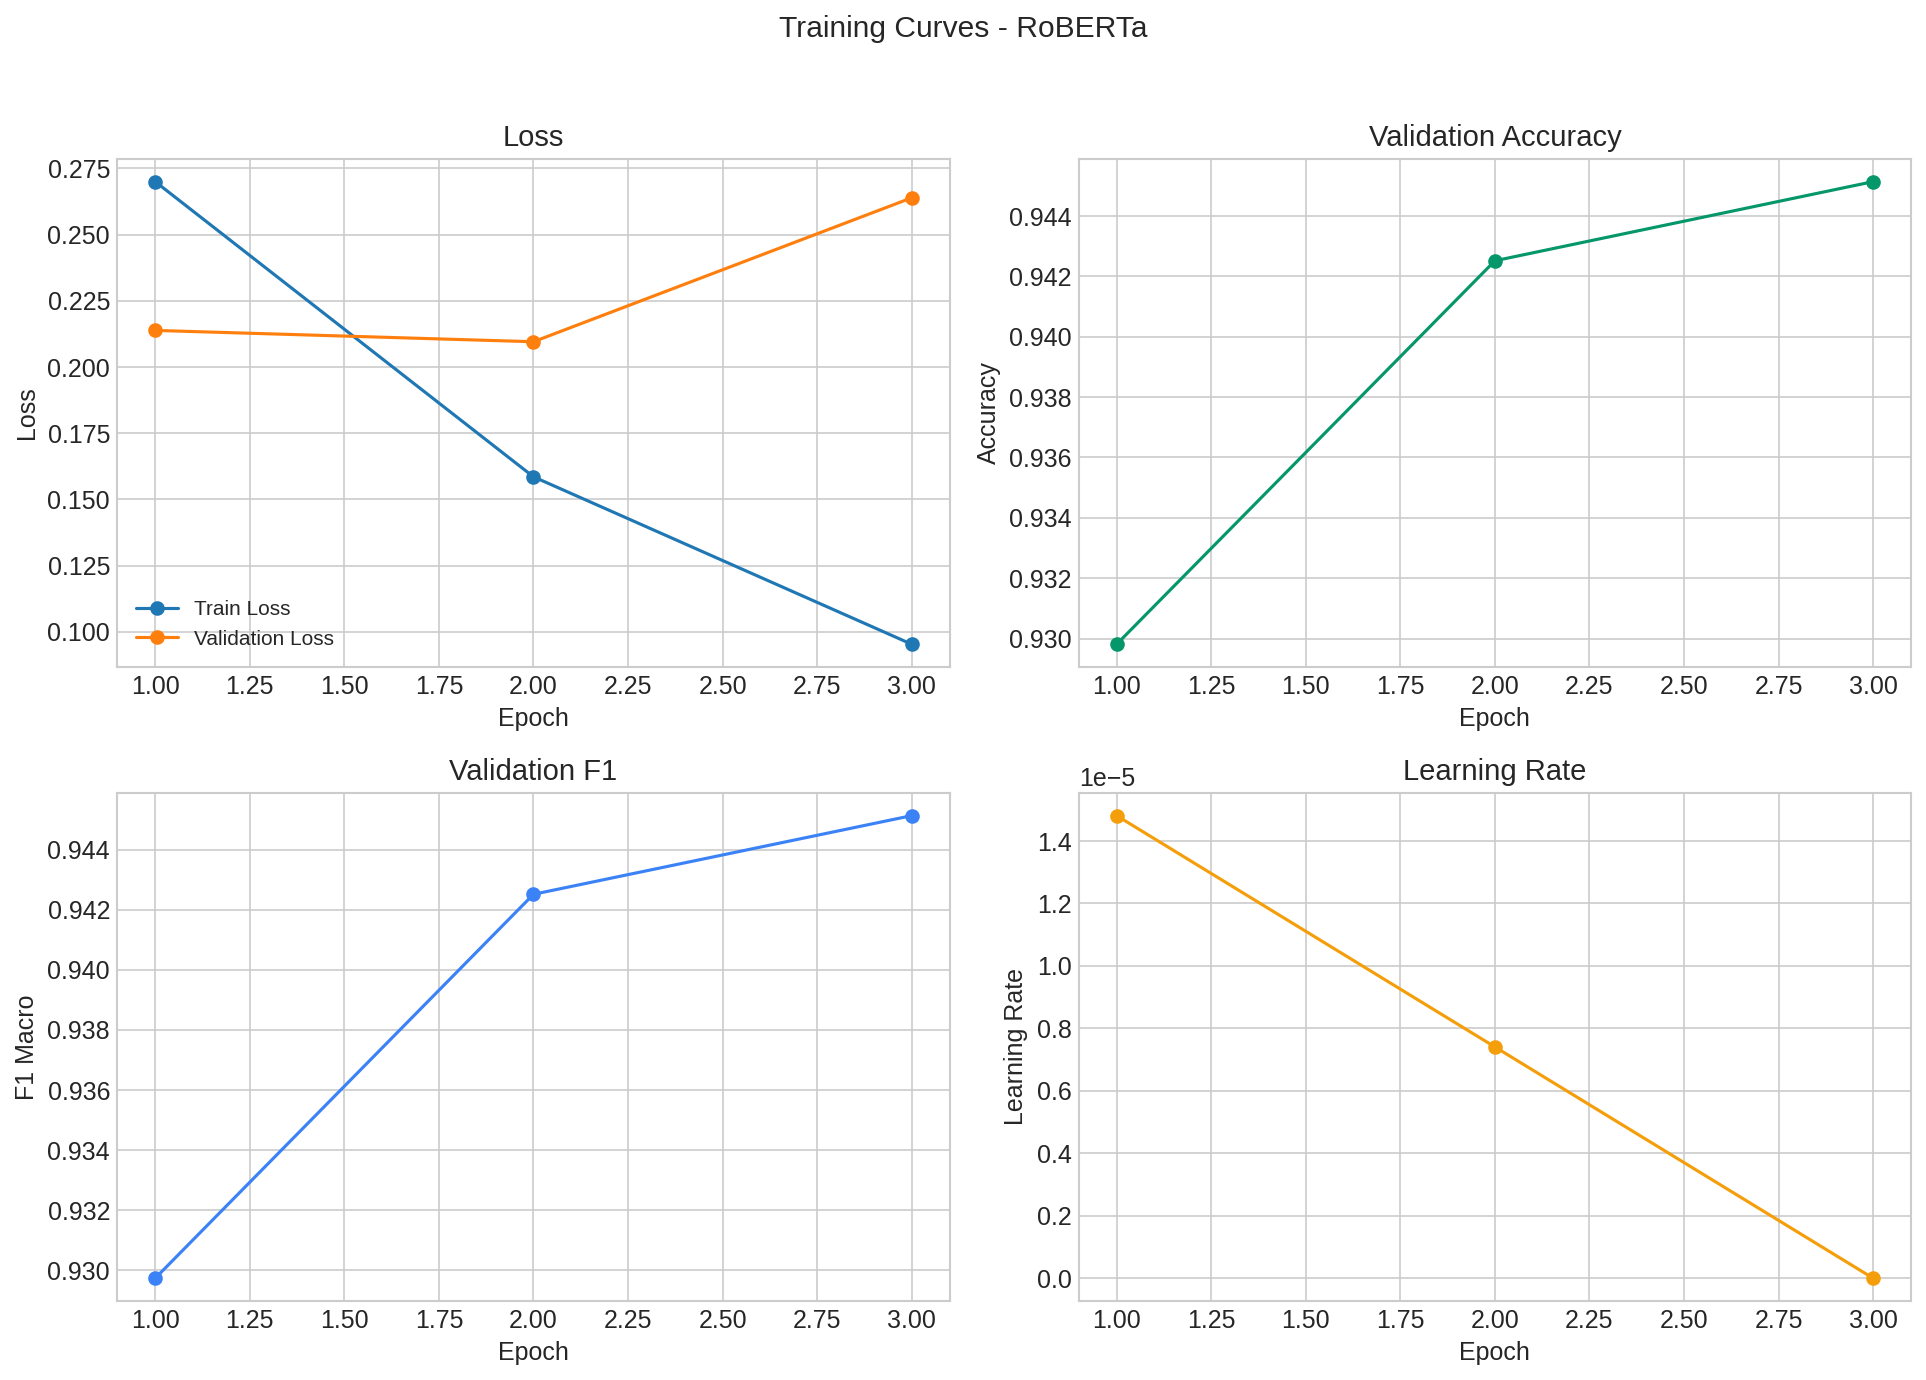

In [13]:
with Timer() as roberta_timer:
    roberta_result = train_utils.train_model(
        "roberta",
        roberta_model,
        roberta_tokenizer,
        roberta_train_loader,
        roberta_val_loader,
        device,
    )

print(f"RoBERTa training time: {roberta_timer}")
display(pd.DataFrame(roberta_result["history"]))

roberta_curve_path = str(Path(config.FIGURES_DIR) / "training_curves_roberta.png")
visualize.plot_training_curves(roberta_result["history"], "RoBERTa", roberta_curve_path)
display(Image(filename=roberta_curve_path))


**Nhận xét:**

RoBERTa đạt validation F1 92.97% ở epoch 1, 94.25% ở epoch 2 và 94.51% ở epoch 3. Đây là validation F1 cao nhất trong ba mô hình. Validation loss tốt nhất là 0.2096 ở epoch 2; đến epoch 3, validation loss tăng lên 0.2639 trong khi train loss tiếp tục giảm xuống 0.0953.

Kết quả này ủng hộ giả thuyết RoBERTa là mô hình mạnh nhất trên validation. Tuy nhiên, việc validation loss tăng ở epoch cuối cho thấy mô hình cũng bắt đầu có dấu hiệu overfitting. Early stopping không kích hoạt vì chỉ có một epoch không cải thiện validation loss trước khi đạt giới hạn 3 epoch. Thời gian huấn luyện là 3,204.74 giây, tương đương khoảng 53 phút 25 giây, gần tương đương BERT-base nhưng cao hơn DistilBERT đáng kể.

Đường cong huấn luyện cho thấy RoBERTa vừa cải thiện validation F1 tốt hơn hai mô hình trước, vừa duy trì validation loss thấp đến epoch 2. Tuy nhiên, sự tăng validation loss ở epoch 3 cho thấy việc kéo dài fine-tuning có thể làm mô hình học sát hơn vào tập train.


### 6.3. Giải phóng bộ nhớ

Sau khi RoBERTa hoàn tất huấn luyện và checkpoint đã được lưu, có thể xóa biến mô hình để giải phóng bộ nhớ. Bước này chuẩn bị cho phần tổng hợp kết quả validation và kiểm tra artifact ở cuối notebook.


In [14]:
del roberta_model
torch.cuda.empty_cache()
gc.collect()


14169

**Nhận xét:**

Bộ nhớ được giải phóng sau khi hoàn tất huấn luyện RoBERTa. Đến thời điểm này, cả ba checkpoint Transformer đã được tạo trong thư mục `models/`, gồm DistilBERT, BERT-base và RoBERTa.

Các kết quả validation được lưu trong log huấn luyện tương ứng và sẽ được tổng hợp ở phần tiếp theo để chọn mô hình ứng viên cho đánh giá test.


## 7. So sánh nhanh trên validation

Bảng dưới đây tổng hợp best validation F1 từ log huấn luyện của ba mô hình. Đây chưa phải kết quả cuối cùng trên test set, nhưng là căn cứ hợp lý để chọn mô hình tốt nhất cho bước đánh giá tiếp theo.

Khi đọc bảng này, cần phân biệt giữa `val_f1` cao nhất và `best_val_loss`. Một mô hình có F1 cao nhất ở một epoch nhưng validation loss tốt nhất ở epoch khác; điều này thường xảy ra khi xác suất dự đoán thay đổi nhưng nhãn phân loại tại ngưỡng mặc định chưa thay đổi tương ứng.


In [15]:
training_results = {
    "distilbert": distilbert_result,
    "bert": bert_result,
    "roberta": roberta_result,
}
validation_rows = []
for model_key, result in training_results.items():
    best_row = max(result["history"], key=lambda row: row["val_f1"])
    validation_rows.append(
        {
            "model": model_key,
            "best_epoch": best_row["epoch"],
            "val_accuracy": best_row["val_accuracy"],
            "val_f1": best_row["val_f1"],
            "val_loss": best_row["val_loss"],
            "train_time_seconds": result["total_train_time_seconds"],
            "best_val_loss": result["best_val_loss"],
        }
    )

validation_comparison = pd.DataFrame(validation_rows).sort_values("val_f1", ascending=False)
display(validation_comparison)


,model,best_epoch,val_accuracy,val_f1,val_loss,train_time_seconds,best_val_loss
2,roberta,3,0.945139,0.945135,0.263925,3204.742985,0.209570
1,bert,2,0.927793,0.927782,0.235368,3196.381603,0.225715
0,distilbert,2,0.921944,0.921940,0.272477,1746.005927,0.262382


**Nhận xét:**

RoBERTa đứng đầu validation với F1 94.51%, BERT-base đứng thứ hai với 92.78%, còn DistilBERT đạt 92.19%. So với DistilBERT, RoBERTa cao hơn 2.32 điểm phần trăm F1 nhưng cần thêm khoảng 1,458.74 giây huấn luyện. So với BERT-base, RoBERTa gần tương đương về thời gian nhưng cao hơn 1.74 điểm phần trăm F1.

Kết quả này cho thấy DistilBERT là lựa chọn tiết kiệm chi phí khi ưu tiên tốc độ, nhưng RoBERTa là ứng viên hợp lý nhất nếu mục tiêu chính là hiệu năng. Vì RoBERTa có F1 cao nhất và thời gian gần tương đương BERT-base, mô hình này được chọn để chuyển sang đánh giá chi tiết trên tập test.

## 8. Kiểm tra artifact đã lưu

Bước cuối cùng kiểm tra lại các artifact được sinh ra trong quá trình huấn luyện. Với mỗi mô hình, notebook kiểm tra thư mục checkpoint, file history log và kích thước mô hình đã lưu.

Việc xác nhận artifact là cần thiết vì notebook tiếp theo sẽ cần nạp lại checkpoint và log huấn luyện để đánh giá test, so sánh mô hình và trực quan hóa kết quả mà không cần fine-tune lại từ đầu.

In [16]:
artifact_rows = []
for model_key, hf_name in config.TRANSFORMER_MODELS.items():
    model_dir = Path(config.MODELS_DIR) / hf_name
    history_path = Path(config.LOG_DIR) / f"{model_key}_history.json"
    total_size_mb = sum(path.stat().st_size for path in model_dir.rglob("*") if path.is_file()) / (1024**2) if model_dir.exists() else 0.0
    artifact_rows.append(
        {
            "model": model_key,
            "model_dir": str(model_dir),
            "model_dir_exists": model_dir.exists(),
            "history_exists": history_path.exists(),
            "model_size_mb": total_size_mb,
        }
    )

display(pd.DataFrame(artifact_rows))


,model,model_dir,model_dir_exists,history_exists,model_size_mb
0,distilbert,/kaggle/working/imdb_sentiment_analysis/models...,True,True,256.104759
1,bert,/kaggle/working/imdb_sentiment_analysis/models...,True,True,418.349782
2,roberta,/kaggle/working/imdb_sentiment_analysis/models...,True,True,478.909420


**Nhận xét:**

Các artifact cần thiết đều đã được tạo và lưu đúng vị trí. Checkpoint đã lưu có kích thước lần lượt khoảng 256.10 MB cho DistilBERT, 418.35 MB cho BERT-base và 478.91 MB cho RoBERTa. Các log huấn luyện đã được ghi vào `models/training_logs/distilbert_history.json`, `models/training_logs/bert_history.json` và `models/training_logs/roberta_history.json`.

Điều này xác nhận pipeline huấn luyện Transformer đã hoàn tất đầy đủ từ fine-tuning, lưu checkpoint đến ghi log thực nghiệm. Các artifact này có thể được tái sử dụng trong notebook đánh giá test và notebook so sánh mô hình mà không cần huấn luyện lại.

## 9. Kết luận

Notebook này hoàn tất quá trình fine-tuning ba mô hình Transformer trên cùng dữ liệu và cùng cấu hình huấn luyện. Kết quả validation cho thấy RoBERTa đạt F1 cao nhất 94.51%, tiếp theo là BERT-base với 92.78% và DistilBERT với 92.19%.

Có thể rút ra ba kết luận chính. Thứ nhất, các mô hình Transformer cải thiện rõ rệt so với baseline TF-IDF + Logistic Regression ở notebook trước, cho thấy lợi ích của biểu diễn ngữ cảnh hóa trong sentiment analysis. Thứ hai, DistilBERT có ưu thế về tốc độ và kích thước mô hình, nhưng đánh đổi bằng validation F1 thấp hơn. Thứ ba, RoBERTa đem lại chất lượng validation tốt nhất với thời gian huấn luyện gần tương đương BERT-base, nên là lựa chọn hợp lý nhất để đưa sang notebook đánh giá test.

Ở bước tiếp theo, checkpoint RoBERTa sẽ được đánh giá trên tập test độc lập để kiểm tra khả năng tổng quát hóa cuối cùng và so sánh trực tiếp với baseline truyền thống.